In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/Telco-Customer-Churn.csv")

print("Shape:", df.shape)

df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [6]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [7]:
df.dropna(inplace=True)

In [8]:
print(df.shape)

df.info()

(7032, 21)
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  

In [9]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [10]:
churn_percent = (
    df["Churn"]
    .value_counts(normalize=True)
    * 100
)

print(churn_percent)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


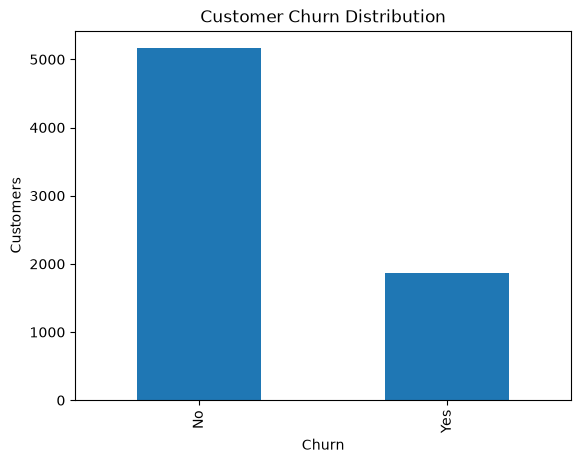

In [11]:
df["Churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customers")

plt.show()

In [12]:
plt.savefig(
    "../visuals/churn_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [13]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


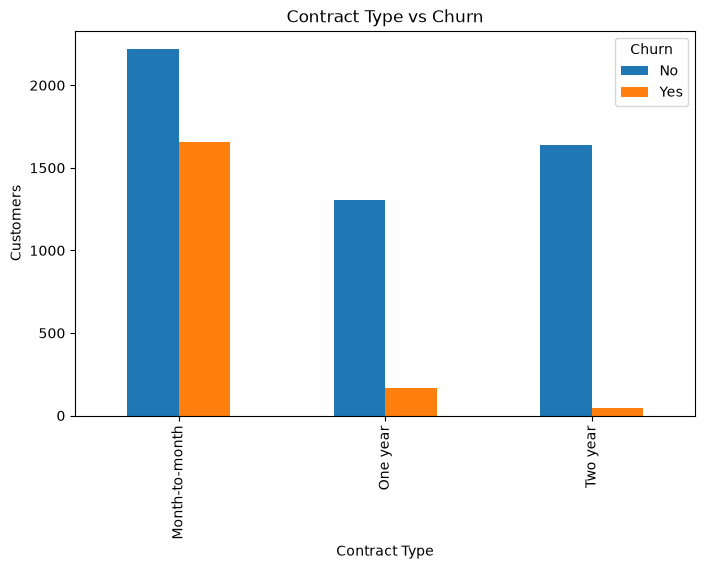

In [14]:
contract_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Customers")

plt.show()

In [15]:
plt.savefig(
    "../visuals/contract_vs_churn.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [16]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [17]:
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [18]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


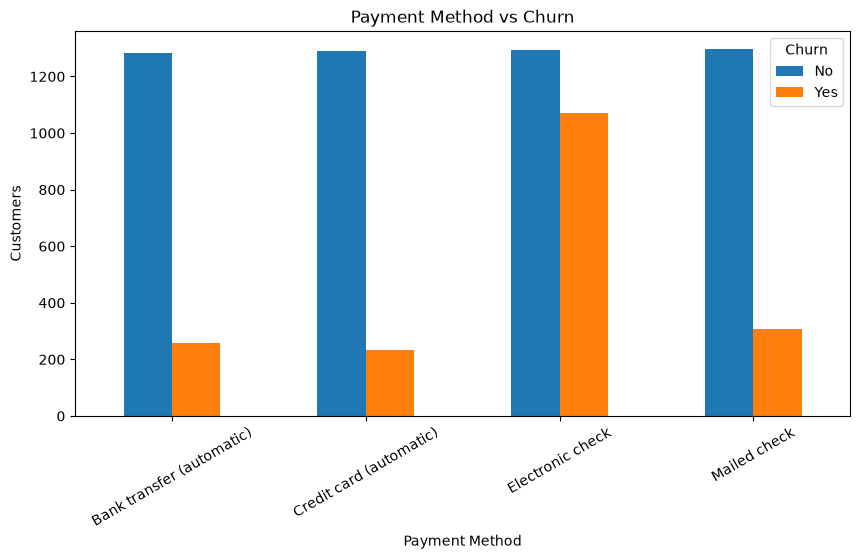

In [19]:
payment_churn.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Customers")
plt.xticks(rotation=30)

plt.show()

In [20]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

internet_churn

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


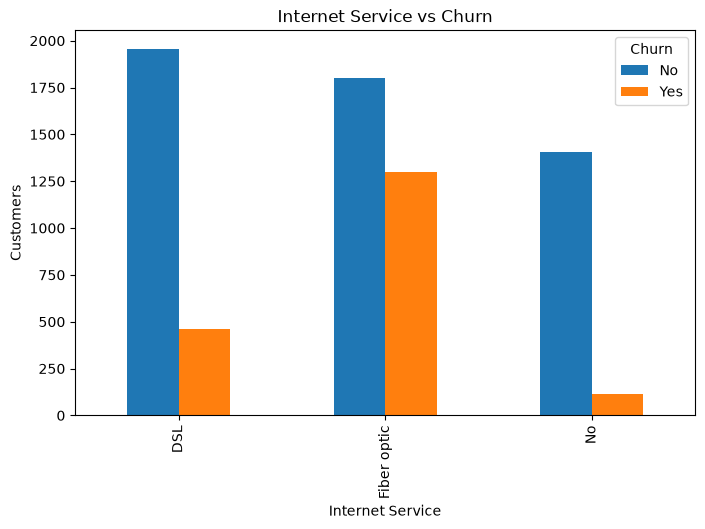

In [21]:
internet_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Customers")

plt.show()

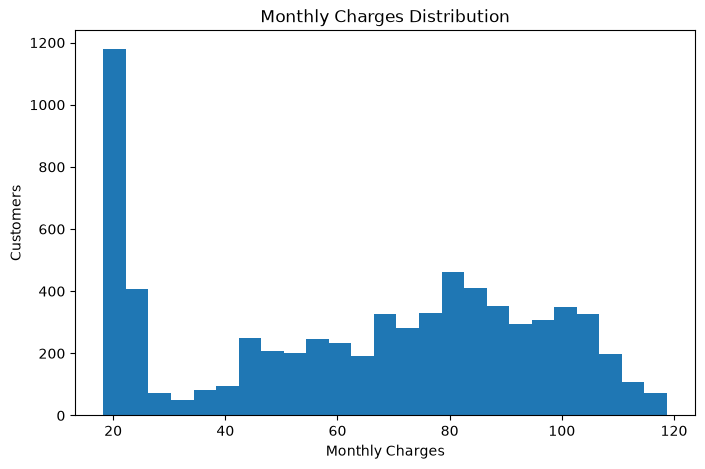

In [22]:
plt.figure(figsize=(8,5))

plt.hist(
    df["MonthlyCharges"],
    bins=25
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Customers")

plt.show()

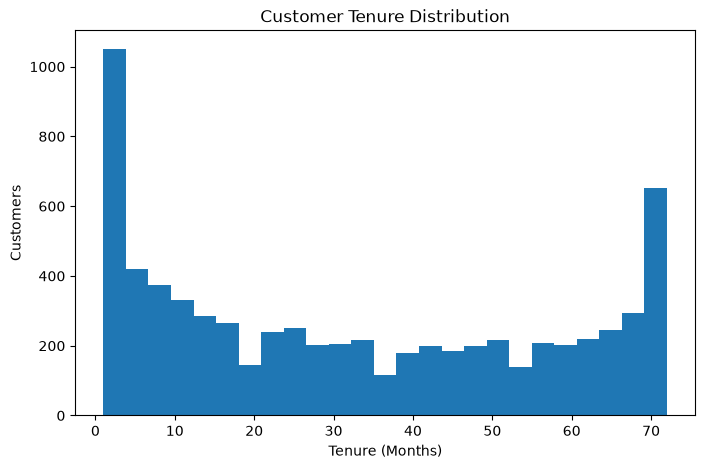

In [23]:
plt.figure(figsize=(8,5))

plt.hist(
    df["tenure"],
    bins=25
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Customers")

plt.show()

In [24]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"]
)

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,4497,1393
1,666,476


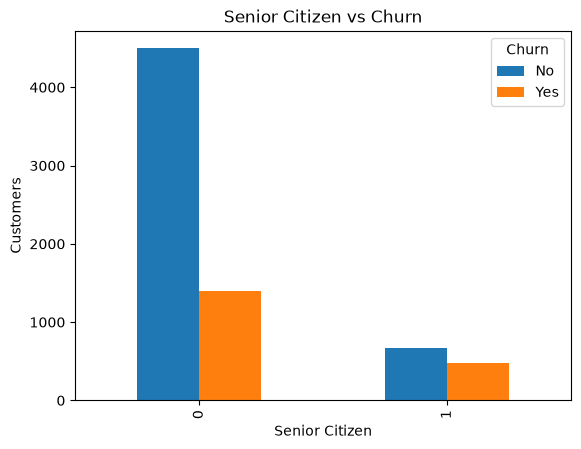

In [25]:
senior_churn.plot(
    kind="bar"
)

plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Customers")

plt.show()

In [26]:
plt.savefig("../visuals/payment_method_churn.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [27]:
plt.savefig("../visuals/payment_method_churn.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [28]:
plt.savefig("../visuals/churn_distribution.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [29]:
plt.savefig("../visuals/contract_vs_churn.png", bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

In [30]:
plt.savefig("../visuals/internet_service_churn.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [31]:
plt.savefig("../visuals/monthly_charges_distribution.png", bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [32]:
plt.savefig("../visuals/tenure_distribution.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [33]:
plt.savefig("../visuals/senior_citizen_churn.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>